### __Imports__

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

### __Data import__

In [30]:
data_rayleigh = np.genfromtxt('data_og_projekt_2026_rayleigh.txt', delimiter="	")

n0_cph = np.genfromtxt("N_værdier.csv",delimiter=",",usecols=0,skip_header=1)
n_cph = np.genfromtxt("N_værdier.csv",delimiter=",",usecols=1,skip_header=1)

n0_gr = np.genfromtxt("N_værdier.csv",delimiter=",",usecols=2,skip_header=1)
n_gr = np.genfromtxt("N_værdier.csv",delimiter=",",usecols=3,skip_header=1)

x_cph = n_cph/n0_cph
y_cph_18 = data_rayleigh[17:33,4]*10**(-3)
y_cph_D = data_rayleigh[17:33,5]*10**(-3)

x_gr = n_gr/n0_gr
y_gr_18 = data_rayleigh[0:16,4]*10**(-3)
y_gr_D = data_rayleigh[0:16,5]*10**(-3)

#### GMWL data import ####

data_GMWL = np.genfromtxt("data_og_projekt_2026_GMWL.csv", delimiter=",", usecols=(3,4),skip_header=1)

d18_GMWL = data_GMWL[:,0]*10**(-3)
dD_GMWL = data_GMWL[:,1]*10**(-3)

sample_names = np.genfromtxt("data_og_projekt_2026_GMWL.csv", delimiter=",",skip_header=1,usecols=1,dtype=str)

### __Definitions and functions__

In [31]:
def chi(x,y,sigma_y,func,*par):
    model = func(x,*par)
    chi_calc = np.sum(((y-(model))/sigma_y)**2)
    print("Chi-kvadrat = ",f"{chi_calc:.2f}")
    chi_red_calc = chi_calc/(len(y)-len(par))
    print("Reduceret chi-kvadrat =", f"{chi_red_calc:.2f}")
    print()
    # return chi_calc, chi_red_calc


def Rayleigh(x, a, b):  
    delta = (1+b)*(x)**(a-1)-1
    return delta

def Rayleigh_log(x,m,c):
    return m*x+c                # Where m = (a-1) and c = ln(b)

def lin(x,a,b):
    return a*x+b


colors = ["lightskyblue","#ff6f6fff","lightskyblue","#ff6f6fff"]      # Errorbars
colors2 = ["darkblue","#9F0808","darkblue","#9F0808"]                 # Data points
colors3 = ["lightskyblue","red","lightskyblue","red"]                     # Fit

x_list = [x_cph,x_cph,x_gr,x_gr]
y_list = [y_cph_18,y_cph_D,y_gr_18,y_gr_D]
L_list = ["$^{18}O$","D","$^{18}O$","D"]
T_list = ["Plot of $\delta^{18}O$ for Copenhagen water","Plot of $\delta D$ for Copenhagen water","Plot of $\delta^{18}O$ for Greenland water","Plot of $\delta D$ for Greenland water"]

yerr_list = [0.000018,0.000122,0.000018,0.000122]
xerr_list = [0.01,0.01,0.01,0.01]

### __Plot of raw data__

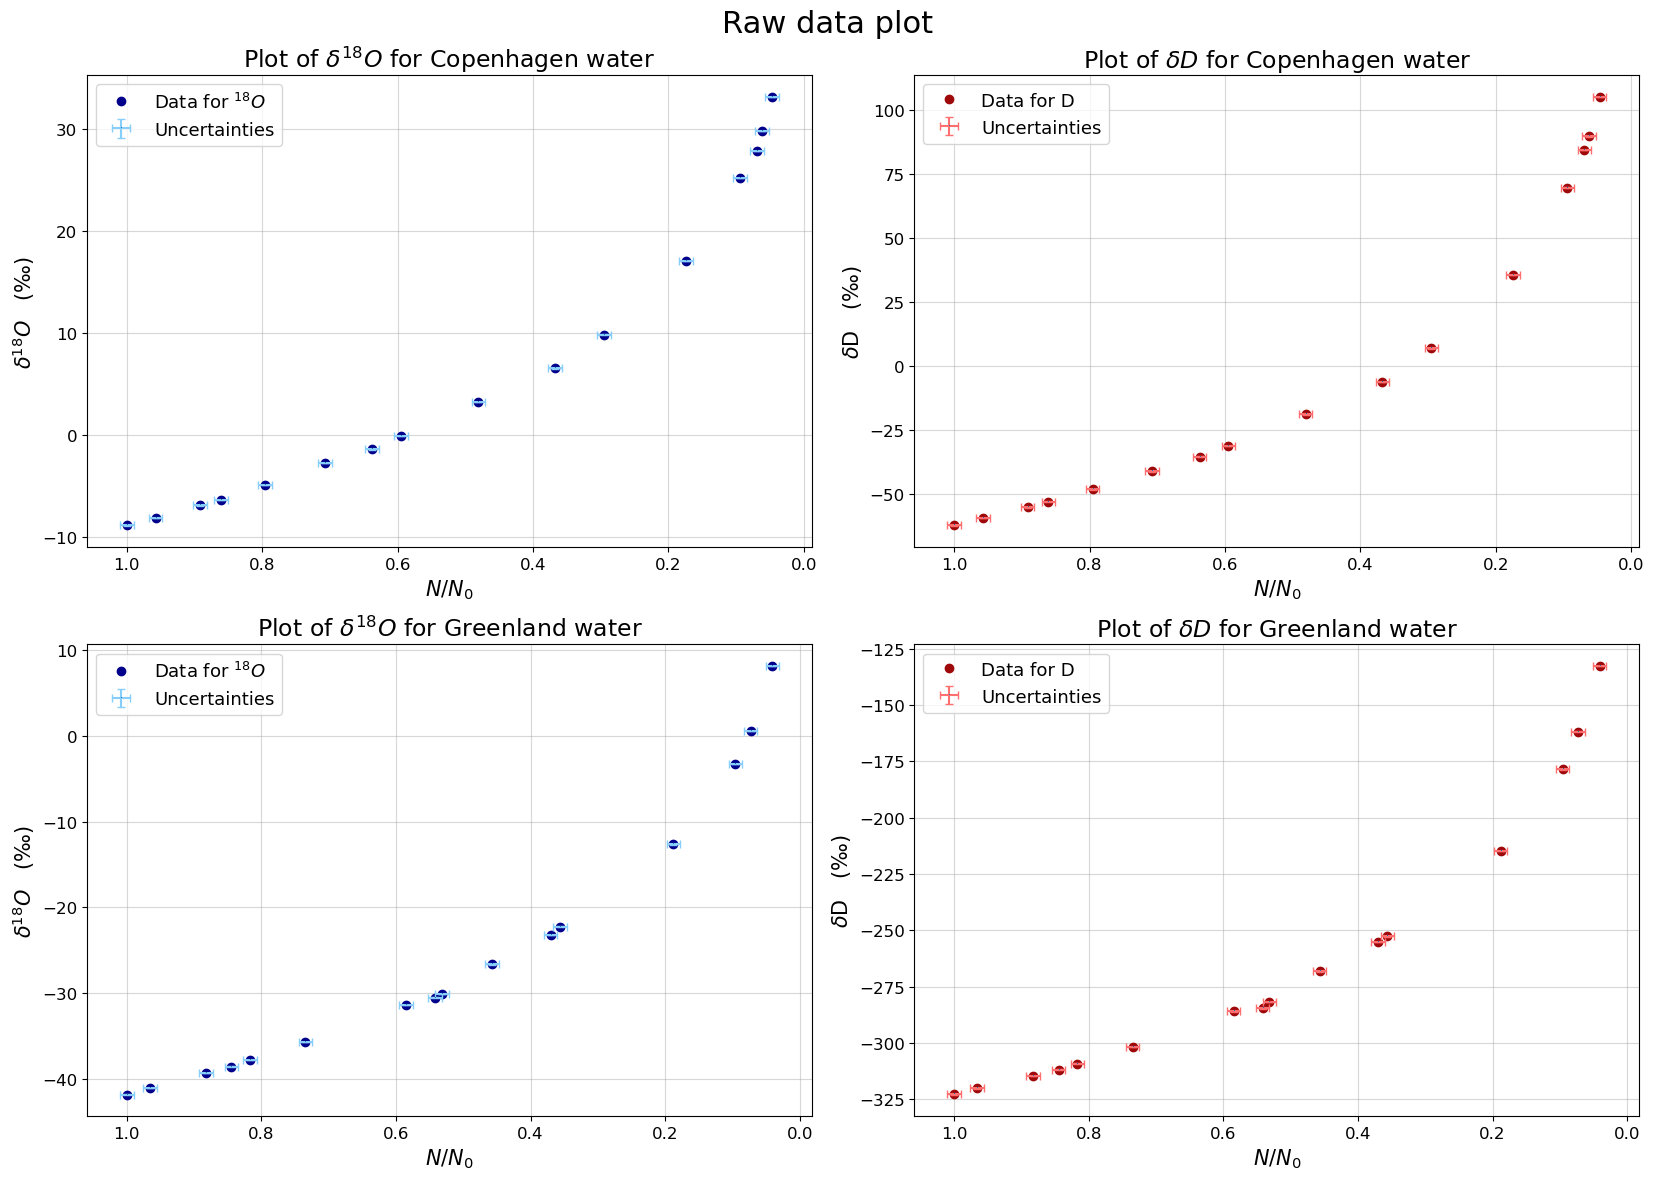

In [32]:
nrows = 2
ncols = 2

fig, ax = plt.subplots(nrows,ncols,figsize=(8.33*ncols,6*nrows))
fig.suptitle("Raw data plot", fontsize = 22)

for ax_i in ax.flat[len(x_list):]:
    ax_i.set_visible(False)

for ax_i, x_data, y_data, L, T, dy, dx, c, c2 in zip(ax.flat,x_list,y_list,L_list,T_list,yerr_list,xerr_list, colors, colors2):

    label = f"Data for {L}"
    
    ax_i.grid(which="both",alpha = 0.5)
    ax_i.plot(x_data,y_data*10**3,"o",label=label,color =c2)
    ax_i.errorbar(x_data,y_data*10**3,xerr=dx,yerr=dy*10**3,fmt=",",capsize=3,label="Uncertainties",ecolor=c)
    ax_i.set_title(f"{T}",fontsize = 17)
    ax_i.set_xlabel("$N/N_0$",fontsize = 15)
    ax_i.set_ylabel(f"$\delta${L}"+"$\quad$"+"(\u2030)",fontsize = 15)
    ax_i.invert_xaxis()
    ax_i.legend(fontsize = 13)
    ax_i.tick_params(axis='both', which='major', labelsize=12)

fig.tight_layout()

# plt.savefig("raw_data_plot",dpi=500,bbox_inches = "tight")

### __Fitting on normal scale__

Curve_fit to the $\delta$-Rayleigh model.

In [33]:
# Empty lists that are to be filled during the for-loop:

par_cph_18 = []
par_cph_D = []
par_gr_18 = []
par_gr_D = []

cov_cph_18 = []
cov_cph_D = []
cov_gr_18 = []
cov_gr_D = []

# These lists will be filled continously during the for-loop

n_list = [par_cph_18, par_cph_D, par_gr_18, par_gr_D]
m_list = [cov_cph_18, cov_cph_D, cov_gr_18, cov_gr_D]

# Curve_fit:

parameter_guess = [1,0]

for x_data, y_data, dy, n, m in zip(x_list,y_list,yerr_list,n_list,m_list):
    r_par, r_cov = sp.optimize.curve_fit(Rayleigh, x_data, y_data, p0=parameter_guess, sigma=dy*np.ones(len(y_data)), absolute_sigma=True)
    n.extend(r_par.tolist())
    m.extend(r_cov.tolist())

# The fit is performed twice. An initial fit is used to estimate the model parameters, which allows the uncertainties in the x-values to be propagated to the y-direction. 
# These propagated uncertainties are then combined with the original y-uncertainties before performing the second and final fit.

#### __Plot of $\delta$-Rayleigh fit__

Plot of $\delta^{18}O$ for Copenhagen water

α =  0.9865 ± 4e-06 ; b = -0.0077 ± 6e-06
Chi-kvadrat =  32624.68
Reduceret chi-kvadrat = 2330.33

Plot of $\delta D$ for Copenhagen water

α =  0.9467 ± 3e-05 ; b = -0.0590 ± 4e-05
Chi-kvadrat =  4478.89
Reduceret chi-kvadrat = 319.92

Plot of $\delta^{18}O$ for Greenland water

α =  0.9839 ± 5e-06 ; b = -0.0403 ± 6e-06
Chi-kvadrat =  70568.11
Reduceret chi-kvadrat = 5040.58

Plot of $\delta D$ for Greenland water

α =  0.9218 ± 4e-05 ; b = -0.3173 ± 4e-05
Chi-kvadrat =  25346.12
Reduceret chi-kvadrat = 1810.44



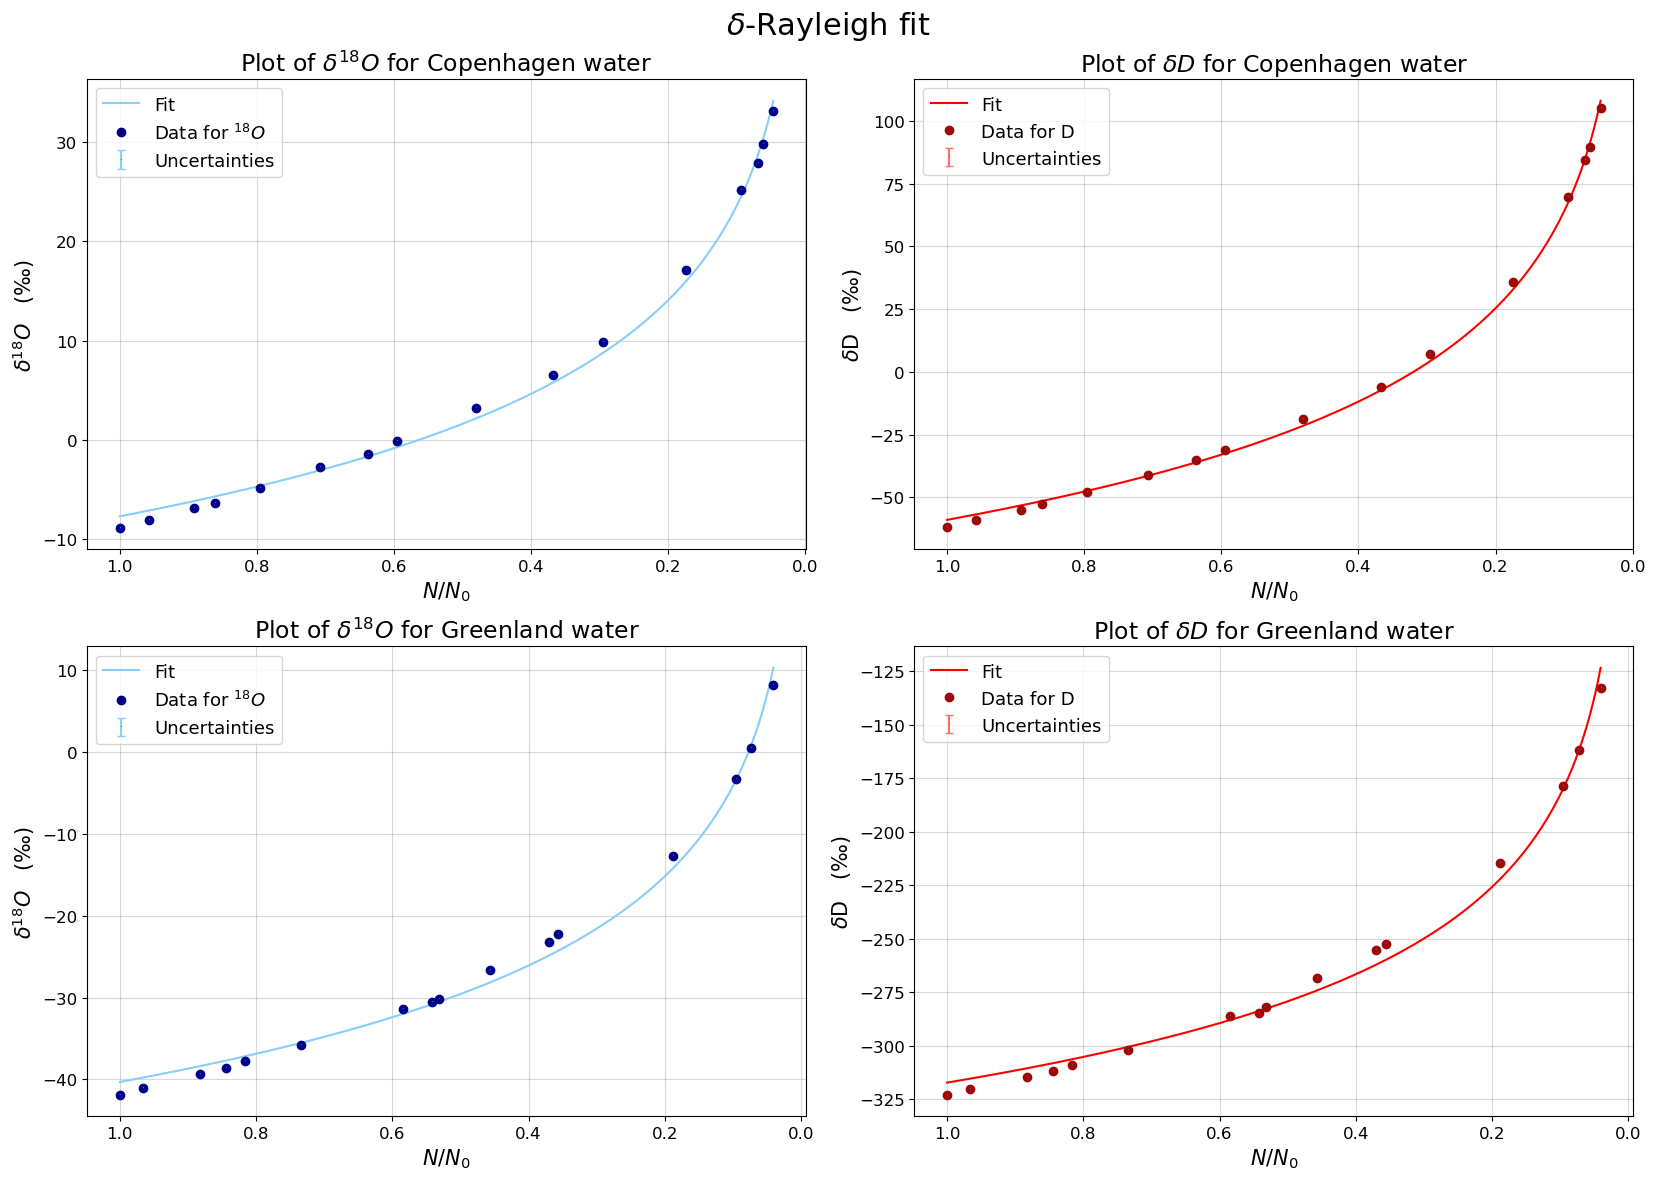

In [34]:
r_par_cph_18_err = []
r_par_cph_D_err = []
r_par_gr_18_err = []
r_par_gr_D_err = []

r_par_err_list = [r_par_cph_18_err, r_par_cph_D_err, r_par_gr_18_err, r_par_gr_D_err]

fig_r, ax_r = plt.subplots(nrows,ncols,figsize=(8.33*ncols,6*nrows))
fig_r.suptitle("$\delta$-Rayleigh fit", fontsize = 22)

for ax_i in ax_r.flat[len(x_list):]:
    ax_i.set_visible(False)

for ax_i, x_data, y_data, dy, L, T, n, m, err, c, c2, c3 in zip(ax_r.flat,x_list,y_list,yerr_list,L_list,T_list,n_list,m_list,r_par_err_list, colors, colors2, colors3):

    label = f"Data for {L}"

    x_model = np.linspace(min(x_data), max(x_data), 1000)
    y_model = Rayleigh(x_model, *n)
    
    ax_i.plot(x_model,y_model*10**3, label = "Fit", color = c3)
    ax_i.errorbar(x_data,y_data*10**3,yerr=dy*10**3,fmt=",",capsize=3,label="Uncertainties",ecolor=c)
    ax_i.plot(x_data,y_data*10**3,"o",label=label,color =c2)
    ax_i.set_title(f"{T}",fontsize = 17)
    ax_i.set_xlabel("$N/N_0$",fontsize = 15)
    ax_i.set_ylabel(f"$\delta${L}"+"$\quad$"+"(\u2030)",fontsize = 15)
    ax_i.invert_xaxis()
    ax_i.grid(alpha = 0.5)
    ax_i.legend(fontsize = 13)
    ax_i.tick_params(axis='both', which='major', labelsize=12)

    r_par_err = np.sqrt(np.diagonal(m))
    err.extend(r_par_err.tolist())


    print(f"{T}")
    print()
    print(f"\u03B1"+" = ",f"{n[0]:.4f} \u00B1 {r_par_err[0]:.0e}","; b =",f"{n[1]:.4f} \u00B1 {r_par_err[1]:.0e}")
    chi(x_data,y_data,dy*np.ones(len(y_data)),Rayleigh,*n)

fig_r.tight_layout()

# plt.savefig("delta-Rayleigh_fit.png",dpi = 500,bbox_inches="tight")



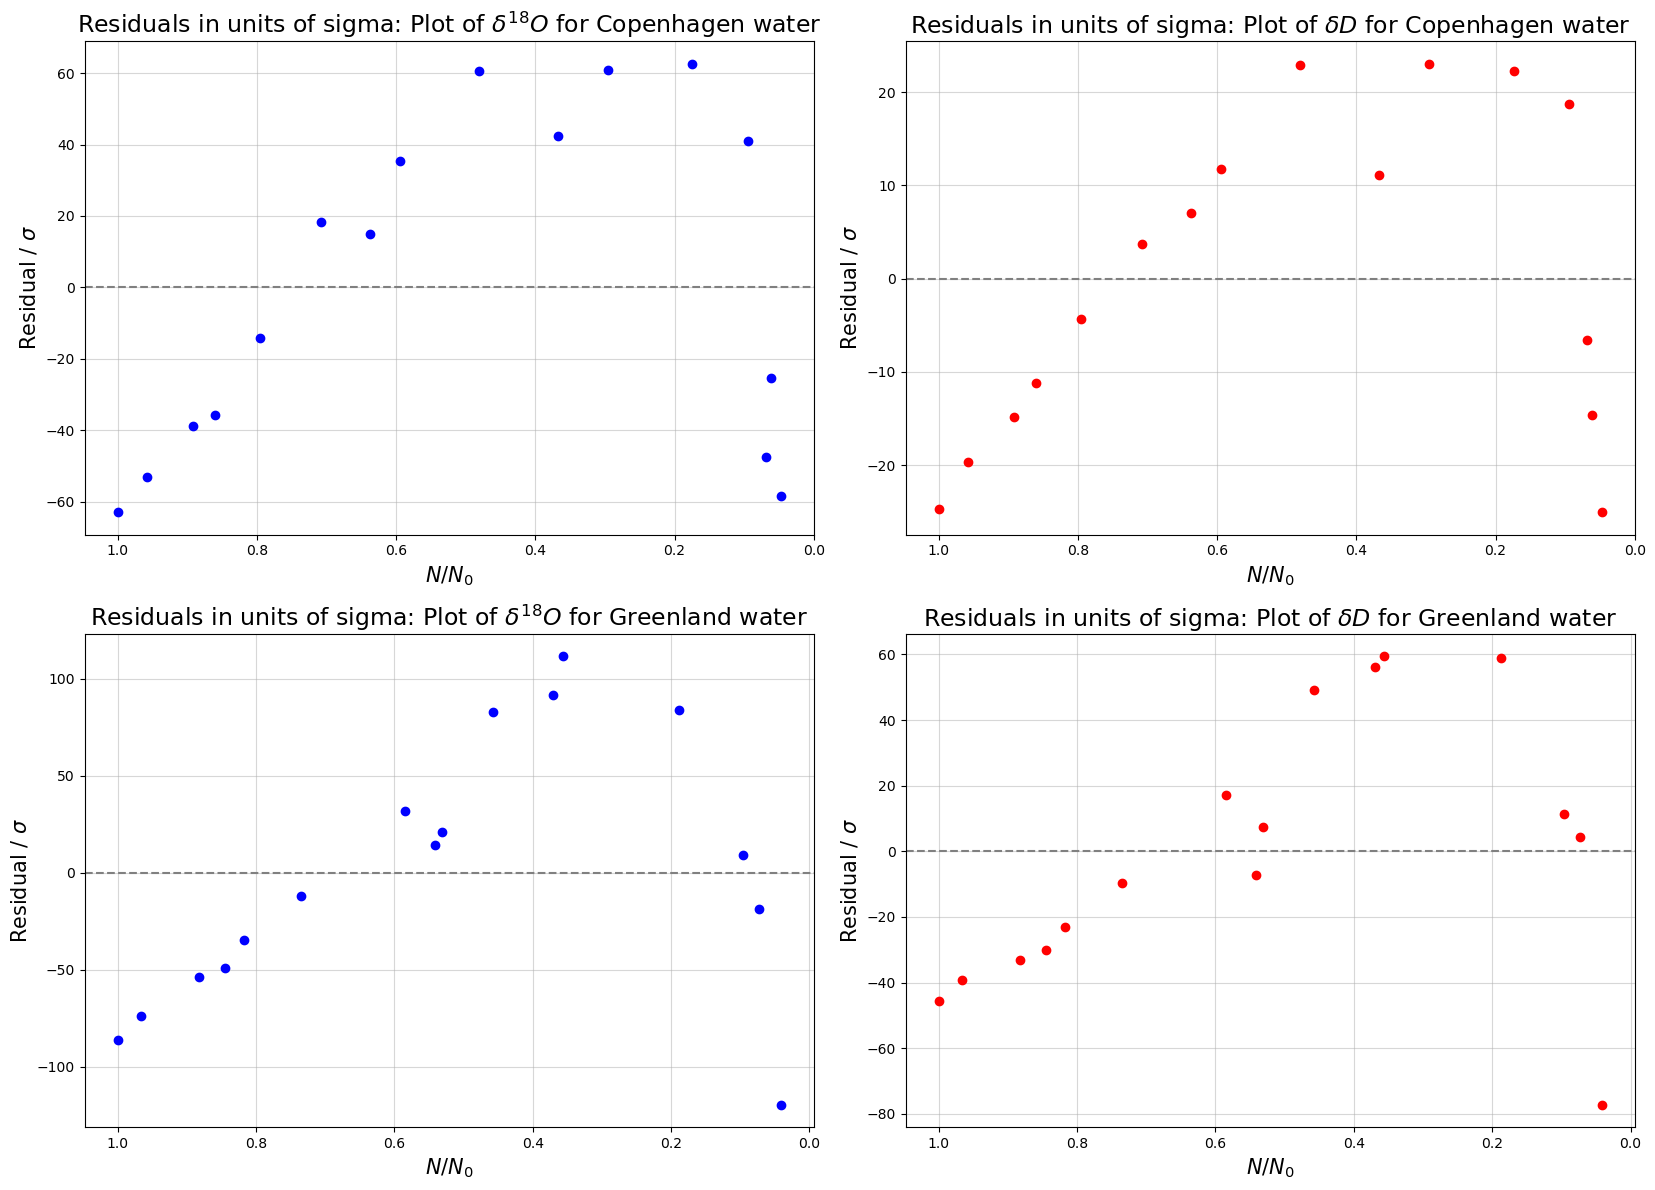

In [35]:
#### Residual plot ####

fig_res, ax_res = plt.subplots(2,2,figsize=(8.33*ncols,6*nrows))
colors4 = ["blue","red","blue","red"]

for ax_res, x_data, y_data, dy, T, n, c4 in zip(ax_res.flat, x_list, y_list, yerr_list, T_list, n_list, colors4):
    
    model = Rayleigh(x_data, *n)
    sigma_arr = dy
    residuals_sigma = (y_data - model) / sigma_arr
    
    ax_res.axhline(0, color='gray', linestyle='--')
    ax_res.plot(x_data, residuals_sigma, 'o', color=c4)
    ax_res.set_xlabel("$N/N_0$", fontsize = 15)
    ax_res.set_ylabel("Residual / $\sigma$", fontsize = 15)
    ax_res.set_title(f"Residuals in units of sigma: {T}", fontsize = 17)
    ax_res.invert_xaxis()
    ax_res.grid(alpha = 0.5)
    ax_i.tick_params(axis='both', which='major', labelsize=12)

fig_res.tight_layout()

# plt.savefig("Residual_rayleigh.png", dpi = 500, bbox_inches = "tight")

### __Fitting on logarithmic scale__

#### __Errors and data__

In [36]:
# ERRORS

ln_usik_cph_18 = yerr_list[0]/(y_cph_18+1)
ln_usik_cph_D = yerr_list[1]/(y_cph_D+1)
ln_usik_gr_18 = yerr_list[2]/(y_gr_18+1)
ln_usik_gr_D  =yerr_list[3]/(y_gr_D+1)

# DATA LOG

ln_x_cph = np.log(n_cph/n0_cph)
ln_y_cph_18 = np.log(y_cph_18+1)        # Instead of delta, R-values are used (therefore +1)
ln_y_cph_D = np.log(y_cph_D+1)

ln_x_gr = np.log(n_gr/n0_gr)
ln_y_gr_18 = np.log(y_gr_18+1)
ln_y_gr_D = np.log(y_gr_D+1)


#### __Curve_fit, plot and chi__

Fit in logspace for $^{18}O$ Copenhagen water

α =  0.9865 ± 4e-06 ; b = -0.0077 ± 6e-06
Chi-kvadrat =  32072.37
Reduceret chi-kvadrat = 2290.88

Fit in logspace for D Copenhagen water

α =  0.9465 ± 3e-05 ; b = -0.0592 ± 4e-05
Chi-kvadrat =  4429.81
Reduceret chi-kvadrat = 316.42

Fit in logspace for $^{18}O$ Greenland water

α =  0.9839 ± 5e-06 ; b = -0.0404 ± 6e-06
Chi-kvadrat =  73624.29
Reduceret chi-kvadrat = 5258.88

Fit in logspace for D Greenland water

α =  0.9210 ± 3e-05 ; b = -0.3178 ± 4e-05
Chi-kvadrat =  43922.29
Reduceret chi-kvadrat = 3137.31



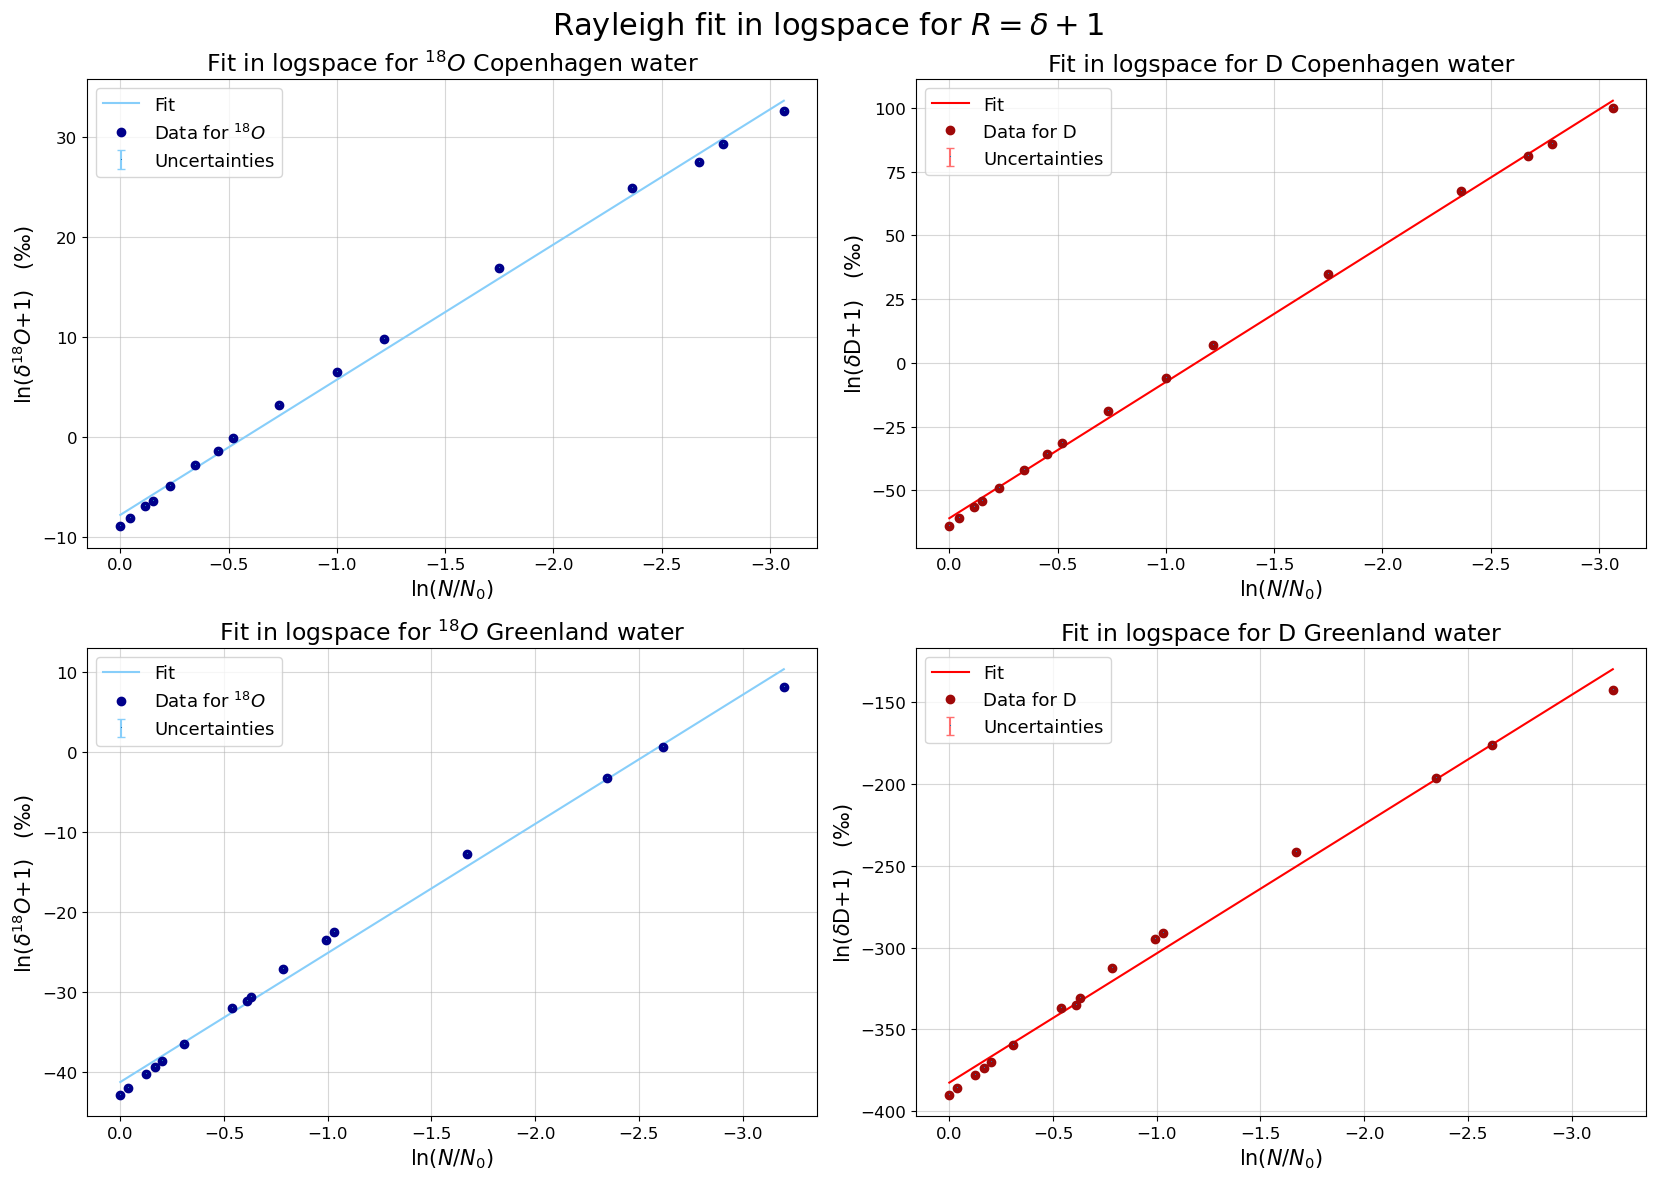

In [37]:
# CURVE_FIT LOG

ln_par_cph_18 = []
ln_par_cph_D = []
ln_par_gr_18 = []
ln_par_gr_D = []

ln_cov_cph_18 = []
ln_cov_cph_D = []
ln_cov_gr_18 = []
ln_cov_gr_D = []

ln_par_cph_18_err = []
ln_par_cph_D_err = []
ln_par_gr_18_err = []
ln_par_gr_D_err = []

ln_x_list = [ln_x_cph,ln_x_cph,ln_x_gr,ln_x_gr]
ln_y_list = [ln_y_cph_18,ln_y_cph_D,ln_y_gr_18,ln_y_gr_D]
ln_L_list = ["$^{18}O$","D","$^{18}O$","D"]
ln_T_list = ["Fit in logspace for $^{18}O$ Copenhagen water","Fit in logspace for D Copenhagen water","Fit in logspace for $^{18}O$ Greenland water","Fit in logspace for D Greenland water"]
ln_n_list = [ln_par_cph_18, ln_par_cph_D, ln_par_gr_18, ln_par_gr_D]
ln_m_list = [ln_cov_cph_18, ln_cov_cph_D, ln_cov_gr_18, ln_cov_gr_D]
ln_par_err_list = [ln_par_cph_18_err, ln_par_cph_D_err, ln_par_gr_18_err, ln_par_gr_D_err]

fig_ln, ax_ln = plt.subplots(nrows,ncols,figsize=(8.33*ncols,6*nrows))
fig_ln.suptitle("Rayleigh fit in logspace for $R = \delta + 1$", fontsize = 22)

for ax_i in ax_ln.flat[len(ln_x_list):]:
    ax_i.set_visible(False)

for ax_i, x_data, y_data, dy, L, T, n, m, err, c, c2, c3 in zip(ax_ln.flat,ln_x_list,ln_y_list,yerr_list, ln_L_list,ln_T_list,ln_n_list,ln_m_list,ln_par_err_list, colors, colors2, colors3):
    
    ln_par, ln_cov = sp.optimize.curve_fit(Rayleigh_log,x_data,y_data,sigma=dy*np.ones(len(y_data)),absolute_sigma=True,p0=[0,y_data[0]])

    n.extend(ln_par.tolist())
    m.extend(ln_cov.tolist())

    label = f"Data for {L}"

    ln_par_err = np.sqrt(np.diagonal(m))
    err.extend(ln_par_err.tolist())

    x_model = np.linspace(min(x_data), max(x_data), 1000)
    y_model = Rayleigh_log(x_model, *n)
    
    ax_i.plot(x_model,y_model*10**3, label = "Fit", color = c3)
    ax_i.errorbar(x_data,y_data*10**3,yerr=dy*10**3,fmt=",",capsize=3,label="Uncertainties",ecolor=c)
    ax_i.plot(x_data,y_data*10**3,"o",label=label,color =c2)
    ax_i.set_title(f"{T}",fontsize = 17)
    ax_i.set_xlabel("$\ln(N/N_0)$",fontsize = 15)
    ax_i.set_ylabel(f"$\ln(\delta${L}+1)"+"$\quad$"+"(\u2030)",fontsize = 15)
    ax_i.invert_xaxis()
    ax_i.grid(alpha = 0.5)
    ax_i.legend(fontsize = 13)
    ax_i.tick_params(axis='both', which='major', labelsize=12)

    print(f"{T}")
    print()
    print(f"\u03B1"+" = ",f"{n[0]+1:.4f} \u00B1 {ln_par_err[0]:.0e}","; b =",f"{np.exp(n[1])-1:.4f} \u00B1 {ln_par_err[1]:.0e}")
    chi(x_data,y_data,dy*np.ones(len(y_data)),Rayleigh_log,*n)

fig_ln.tight_layout()

# plt.savefig("Rayleigh_logspace_fit.png",dpi=500,bbox_inches = "tight")

### __dD as a function of dO-18__

Slope =  3.968 ± 2e-03 ; intercept = -0.029 ± 3e-05

Slope =  3.810 ± 2e-03 ; intercept = -0.166 ± 6e-05



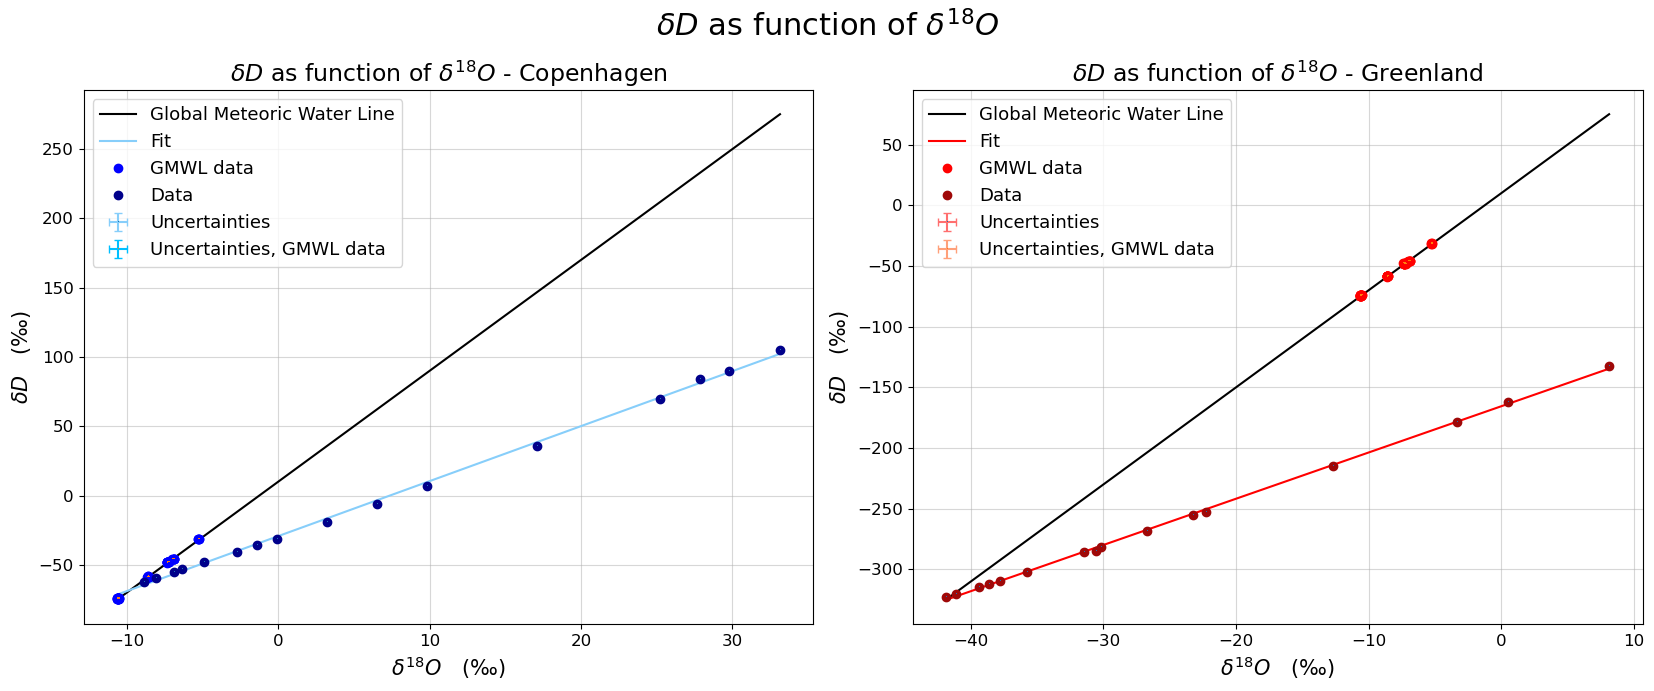

In [38]:
usik_cph = []
usik_gr  =[]

par_cph = []
par_gr = []

cov_cph = []
cov_gr = []

m_x_list = [y_cph_18,y_gr_18]
m_y_list = [y_cph_D,y_gr_D]
m_yerr_list = [0.000122,0.000122]
m_xerr_list = [0.000018,0.000018]

x_list_GMWL = [d18_GMWL,d18_GMWL]
y_list_GMWL = [dD_GMWL,dD_GMWL]
xerr_GMWL_list = [0.000013,0.000013]
yerr_GMWL_list = [0.000088,0.000088]

colors5 = [["blue","deepskyblue"],["red","lightsalmon"]]

m_L_list = ["label","label"]
m_T_list = ["$\delta D$ as function of $\delta^{18}O$ - Copenhagen","$\delta D$ as function of $\delta^{18}O$ - Greenland"]
m_n_list = [par_cph, par_gr]
m_m_list = [cov_cph, cov_gr]

nrows = 1
ncols = 2

fig_m, ax_m = plt.subplots(nrows,ncols,figsize=(8.33*ncols,6*nrows+1))
fig_m.suptitle("$\delta D$ as function of $\delta^{18}O$", fontsize = 22)

for ax_i in ax_m.flat[len(m_x_list):]:
    ax_i.set_visible(False)


for ax_i, x_data, y_data, dy, dx, x_GMWL, y_GMWL, dx_GMWL, dy_GMWL, L, T, n, m, c, c2, c3, c5 in zip(ax_m.flat,m_x_list,m_y_list,m_yerr_list,m_xerr_list,x_list_GMWL,y_list_GMWL, xerr_GMWL_list, yerr_GMWL_list, m_L_list,m_T_list,m_n_list,m_m_list, colors, colors2, colors3, colors5):

    m_par, m_cov = sp.optimize.curve_fit(lin, x_data, y_data, sigma=dy*np.ones(len(y_data)), absolute_sigma=True)

    n.extend(m_par.tolist())
    m.extend(m_cov.tolist())

    label = "Data"

    x_model = np.linspace(min(np.min(x_GMWL),np.min(x_data)), max(np.max(x_GMWL),np.max(x_data)), 1000)
    y_model = lin(x_model, *n)

    y_meteoric = lin(x_model*10**3,8,10)

    m_par_err = np.sqrt(np.diagonal(m))

    ax_i.plot(x_model*10**3,y_meteoric,label = "Global Meteoric Water Line",color="black")
    ax_i.plot(x_model*10**3,y_model*10**3, label = "Fit", color = c3)
    ax_i.errorbar(x_data*10**3,y_data*10**3,xerr=dx*10**3,yerr=dy*10**3,fmt=",",capsize=3,label="Uncertainties",ecolor=c)
    ax_i.errorbar(x_GMWL*10**3,y_GMWL*10**3,xerr=dx_GMWL*10**3,yerr=dy_GMWL*10**3,fmt=",",capsize=3,label="Uncertainties, GMWL data",ecolor=c5[1])
    ax_i.plot(x_GMWL*10**3,y_GMWL*10**3,"o",label="GMWL data",color=c5[0])
    ax_i.plot(x_data*10**3,y_data*10**3,"o",label=label,color=c2)
    ax_i.set_title(f"{T}", fontsize = 17)
    ax_i.set_ylabel("$\delta D$"+"$\quad$"+"(\u2030)", fontsize = 15)
    ax_i.set_xlabel("$\delta^{18}O$"+"$\quad$"+"(\u2030)", fontsize = 15)
    ax_i.grid(alpha = 0.5)
    ax_i.legend(fontsize = 13)
    ax_i.tick_params(axis='both', which='major', labelsize=12)

    print(f"Slope"+" = ",f"{n[0]:.3f} \u00B1 {m_par_err[0]:.0e}","; intercept =",f"{n[1]:.3f} \u00B1 {m_par_err[1]:.0e}\n")


    # fit_text = rf"$\delta D = ({slope:.3f} \pm {slope_err:.0e}) \cdot \delta^{{18}}O + ({intercept:.3e} \pm {intercept_err:.0e}) $"
    # ax_i.text(0.95, 0.05, fit_text,transform=ax_i.transAxes, fontsize=10, ha="right",va="bottom")

fig_m.tight_layout()

# plt.savefig("delta-D_vs_delta_O-18.png",dpi=500,bbox_inches = "tight")


### __Temp as function of time__

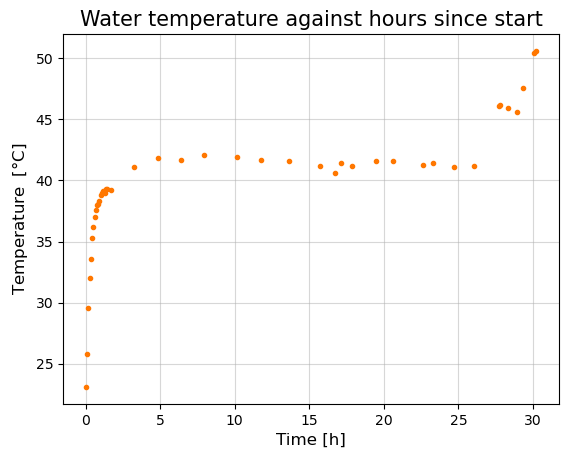

In [39]:
hours = np.genfromtxt("Temp.csv",delimiter=",", usecols=0)
temp = np.genfromtxt("Temp.csv",delimiter=",", usecols=1)

plt.plot(hours,temp,".", label="Data", color="#FF7700")
plt.xlabel("Time [h]",fontsize = 12)
plt.ylabel(r"Temperature $\;[\degree\text{C}]$",fontsize = 12)
plt.title("Water temperature against hours since start",fontsize = 15)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.grid(alpha = 0.5)

# plt.savefig("temp vs time.png",dpi=500,bbox_inches ="tight")


### __Teoretisk alpha og alpha_kin__

In [40]:
############# THEORETICAL ALPHAS #############

# O-18

def O_alpha(t,write = False):
    T = t + 273.15
    a = float(np.exp((-1137/(T**2)) + (0.4156/T) + 0.0020667))
    if write:
        print(f"Temp: {t}\u00B0, \u03B1:",f"{a:.4f}")
    return a

print("O-18 fractionation factors:\n")

O_a_42 = O_alpha(42,True);
O_a_45 = O_alpha(45,True);
O_a_50 = O_alpha(50,True);

O_a = [O_a_42,O_a_45,O_a_50]

# Deuterium:

def D_alpha(t, write = False):
    T = t + 273.15
    a = float(np.exp(-24844/(T**2) + (76.248/T) - 0.052612))
    if write:
        print(f"Temp: {t}\u00B0, \u03B1:",f"{a:.4f}")
    return a

print("\nDeuterium fractionation factors:\n")

D_a_42 = D_alpha(42,True);
D_a_45 = D_alpha(45,True);
D_a_50 = D_alpha(50,True);

D_a = [D_a_42,D_a_45,D_a_50]



O-18 fractionation factors:

Temp: 42°, α: 0.9920
Temp: 45°, α: 0.9922
Temp: 50°, α: 0.9925

Deuterium fractionation factors:

Temp: 42°, α: 0.9410
Temp: 45°, α: 0.9433
Temp: 50°, α: 0.9469


In [41]:
t_list = [[42,50],[42,50]]
T_kin_list = [["CPH O-18 Rayleigh, temp. 42:  ","CPH O-18 log, temp. 42:  ","CPH O-18 Rayleigh, temp. 50: ","CPH O-18 log, temp. 50: ",
              "CPH D Rayleigh, temp. 42:  ","CPH D log, temp. 42:  ","CPH D Rayleigh, temp. 50: ","CPH D log, temp. 50: "],
              
              ["GR O-18 Rayleigh, temp. 42:  ","GR O-18 log, temp. 42:  ","GR O-18 Rayleigh, temp. 50: ","GR O-18 log, temp. 50: ",
              "GR D Rayleigh, temp. 42:  ","GR D log, temp. 42:  ","GR D Rayleigh, temp. 50: ","GR D log, temp. 50: "]]


# Fit alphas:

a_r = np.array(n_list)[:,0]                                     
a_ln = (np.array(ln_n_list)+1)[:,0]

O_a_r_fit = a_r[[0,2]]
O_a_ln_fit = a_ln[[0,2]]

D_a_r_fit = a_r[[1,3]]
D_a_ln_fit = a_ln[[1,3]]

# Errors for fit alphas:

r_a_err = np.array(r_par_err_list)[:,0]
ln_a_err = np.array(ln_par_err_list)[:,0]

O_a_r_err = r_a_err[[0,2]]
O_a_ln_err = ln_a_err[[0,2]]

D_a_r_err = r_a_err[[1,3]]
D_a_ln_err = ln_a_err[[1,3]]

# print(err_list)

for t, O_r_p, O_ln_p, D_r_p, D_ln_p, O_r_err, O_ln_err, D_r_err, D_ln_err, T_kin in zip(t_list, O_a_r_fit, O_a_ln_fit, D_a_r_fit, D_a_ln_fit, O_a_r_err, O_a_ln_err, D_a_r_err, D_a_ln_err, T_kin_list):
    
    # Calculate theoretical (equilibrium) alphas:
    
    Ox_a_42 = O_alpha(t[0])
    Ox_a_50 = O_alpha(t[1])

    De_a_42 = D_alpha(t[0])
    De_a_50 = D_alpha(t[1])

    # Calculate kinetic alphas:

    Ox_a_r_kin_42 = O_r_p/Ox_a_42
    Ox_a_ln_kin_42 = O_ln_p/Ox_a_42

    Ox_a_r_kin_50 = O_r_p/Ox_a_50
    Ox_a_ln_kin_50 = O_ln_p/Ox_a_50

    De_a_r_kin_42 = D_r_p/De_a_42
    De_a_ln_kin_42 = D_ln_p/De_a_42

    De_a_r_kin_50 = D_r_p/De_a_50
    De_a_ln_kin_50 = D_ln_p/De_a_50

    # Concatenate values: first loop is CPH and second loop is GR:

    a_kin = [Ox_a_r_kin_42,Ox_a_ln_kin_42,Ox_a_r_kin_50,Ox_a_ln_kin_50,De_a_r_kin_42,De_a_ln_kin_42,De_a_r_kin_50,De_a_ln_kin_50]
        
    # Calculate uncertainty on kinetic alphas:

    Ox_a_r_kin_42_err = O_r_err/Ox_a_42
    Ox_a_ln_kin_42_err = O_ln_err/Ox_a_42

    Ox_a_r_kin_50_err = O_r_err/Ox_a_50
    Ox_a_ln_kin_50_err = O_ln_err/Ox_a_50

    De_a_r_kin_42_err = D_r_err/De_a_42
    De_a_ln_kin_42_err = D_ln_err/De_a_42

    De_a_r_kin_50_err = D_r_err/De_a_50
    De_a_ln_kin_50_err = D_ln_err/De_a_50

    a_kin_err = [Ox_a_r_kin_42_err,Ox_a_ln_kin_42_err,Ox_a_r_kin_50_err,Ox_a_ln_kin_50_err,De_a_r_kin_42_err,De_a_ln_kin_42_err,De_a_r_kin_50_err,De_a_ln_kin_50_err]

    for x, e, y in zip(a_kin, a_kin_err, T_kin):
        print(f"{y:<30} {float(x):>8.4f}  \u00B1  {float(e):>2.0e}")

CPH O-18 Rayleigh, temp. 42:     0.9945  ±  4e-06
CPH O-18 log, temp. 42:          0.9945  ±  4e-06
CPH O-18 Rayleigh, temp. 50:     0.9940  ±  4e-06
CPH O-18 log, temp. 50:          0.9939  ±  4e-06
CPH D Rayleigh, temp. 42:        1.0060  ±  3e-05
CPH D log, temp. 42:             1.0059  ±  3e-05
CPH D Rayleigh, temp. 50:        0.9998  ±  3e-05
CPH D log, temp. 50:             0.9996  ±  3e-05
GR O-18 Rayleigh, temp. 42:      0.9919  ±  5e-06
GR O-18 log, temp. 42:           0.9919  ±  5e-06
GR O-18 Rayleigh, temp. 50:      0.9914  ±  5e-06
GR O-18 log, temp. 50:           0.9913  ±  5e-06
GR D Rayleigh, temp. 42:         0.9796  ±  4e-05
GR D log, temp. 42:              0.9788  ±  3e-05
GR D Rayleigh, temp. 50:         0.9735  ±  4e-05
GR D log, temp. 50:              0.9727  ±  3e-05


### _Skal formentlig ikke bruges_

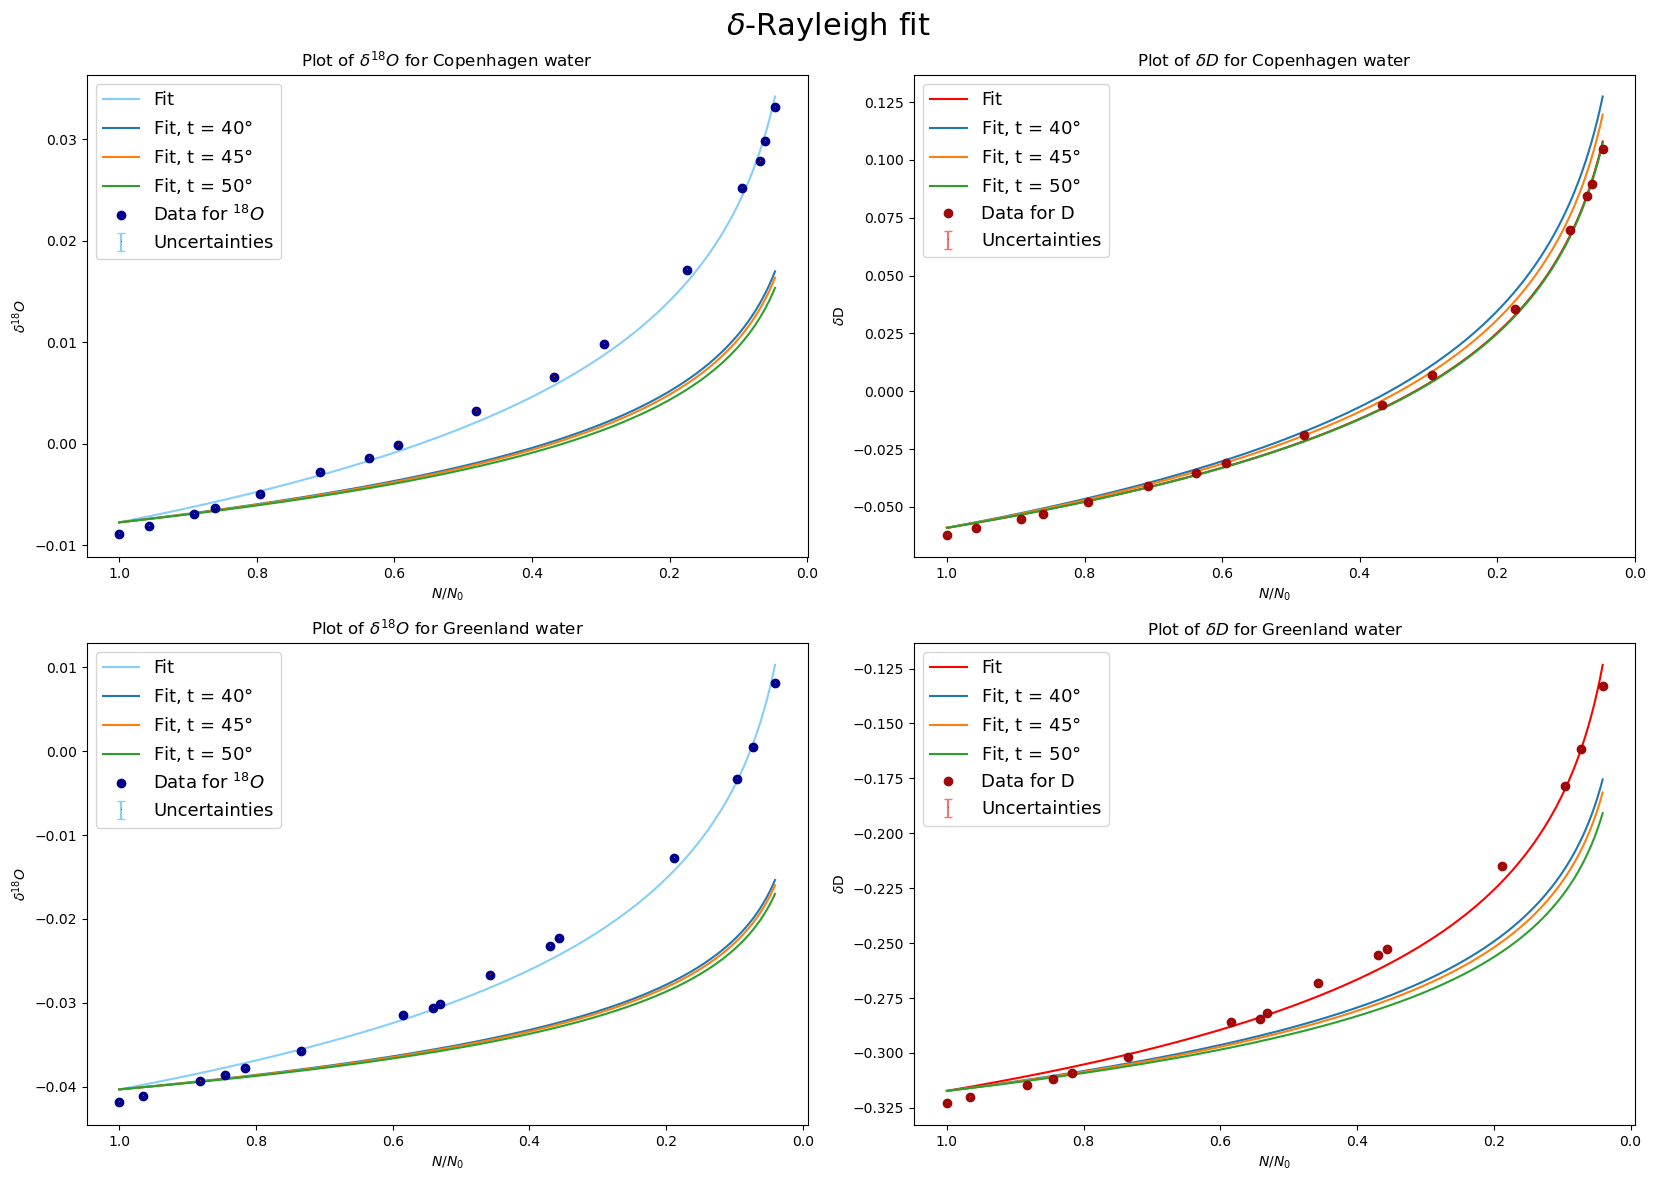

In [42]:
### PLOT AF RAYLEIGH MODEL TIL FORSKELLIGE ALPHA VÆRDIER ###

a_list = [O_a,D_a,O_a,D_a]

nrows = 2
ncols = 2

fig, ax = plt.subplots(nrows,ncols,figsize=(8.33*ncols,6*nrows))
fig.suptitle("$\delta$-Rayleigh fit", fontsize = 22)

for ax_i in ax.flat[len(x_list):]:
    ax_i.set_visible(False)

for ax_i, x, y, L, T, n , a, c, c2, c3 in zip(ax.flat,x_list,y_list,L_list,T_list,n_list, a_list, colors, colors2, colors3):

    label = f"Data for {L}"

    X = np.linspace(min(x), max(x), 1000)
    Y = Rayleigh(X, *n)
    
    Y_40 = Rayleigh(X,a[0],n[1])
    Y_45 = Rayleigh(X,a[1],n[1])
    Y_50 = Rayleigh(X,a[2],n[1])

    ax_i.plot(X,Y, label = "Fit", color = c3)
    ax_i.plot(X,Y_40, label = r"Fit, t = 40$\degree$")
    ax_i.plot(X,Y_45, label = r"Fit, t = 45$\degree$")
    ax_i.plot(X,Y_50, label = r"Fit, t = 50$\degree$")
    ax_i.errorbar(x,y,yerr=dy,fmt=",",capsize=3,label="Uncertainties",ecolor=c)
    ax_i.plot(x,y,"o",label=label,color =c2)
    ax_i.set_title(f"{T}")
    ax_i.set_xlabel("$N/N_0$")
    ax_i.set_ylabel(f"$\delta${L}")
    ax_i.invert_xaxis()
    ax_i.legend(fontsize = 13)

fig.tight_layout()